# Ejecución y validación del Índice de Idoneidad Agrícola (IAI)

Este notebook aplica la fórmula del IAI sobre el conjunto de datos histórico de California
y valida el índice resultante. Se organiza en cuatro partes:

1. **Cálculo del IAI** — aplicación de la fórmula sobre los datos históricos.
2. **Análisis de sensibilidad** — robustez del índice ante distintas ponderaciones.
3. **Análisis exploratorio (EDA)** — relación del IAI con sus subíndices y con las variables base.
4. **Resumen por cultivo** — idoneidad media y distribución de cada cultivo.

El motor de cálculo del índice se importa desde `src/IAI_estimador_V3.py`.

## 1. Configuración e importación de datos

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.feature_selection import mutual_info_regression

# Importar el motor lógico del IAI desde src/
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)
from src.IAI_estimador_V2 import calculate_iai, CROP_AGRONOMIC_SETTINGS

In [2]:
# Carpeta de salida para las figuras
OUTPUT_DIR = "resultados_IAI"
os.makedirs(OUTPUT_DIR, exist_ok=True)

def save(fig, name):
    """Guarda una figura en la carpeta de resultados."""
    path = os.path.join(OUTPUT_DIR, name)
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"  [guardado] {path}")

In [3]:
# Cargar el dataset histórico limpio
df_hist_clean = pl.read_parquet("C:/Users/lesli/Documents/TFM/Data/hist_clean.parquet")
print("Filas totales:", df_hist_clean.shape[0])

Filas totales: 633904


## 2. Cálculo del IAI

Se aplica la función `calculate_iai`, que calcula los cuatro subíndices
(temperatura, frío invernal, precipitación y suelo) y los combina en el índice final.

In [4]:
# Aplicar la función vectorizada del IAI
df_iai_hist = calculate_iai(df_hist_clean)
iai_values = df_iai_hist["IAI"].to_numpy()
print(f"IAI calculado para {len(iai_values):,} observaciones.")

IAI calculado para 633,904 observaciones.


  [guardado] resultados_IAI\hist_distribucion_iai_nt.png


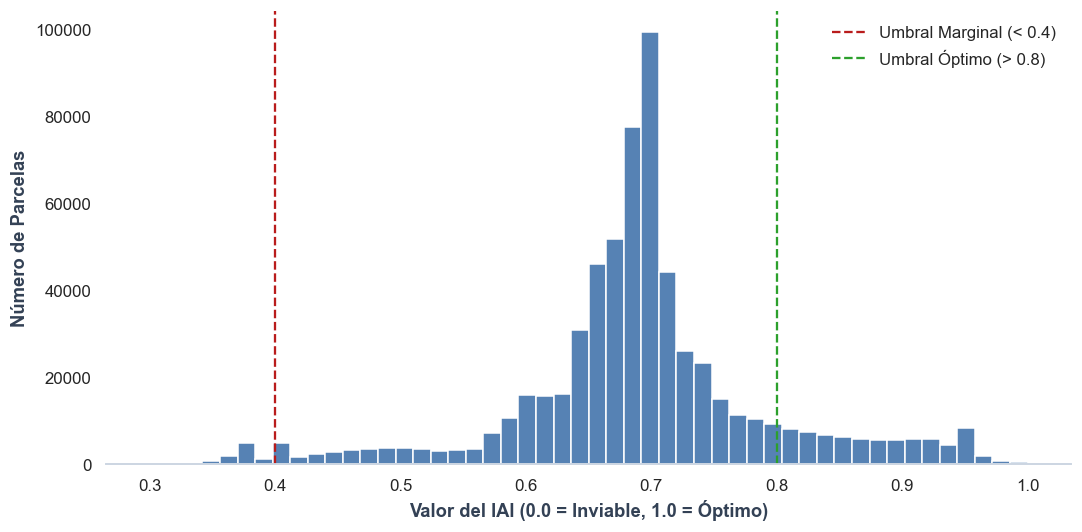

statistic,IAI
str,f64
"""count""",633904.0
"""null_count""",0.0
"""mean""",0.6916
"""std""",0.102815
"""min""",0.3
"""25%""",0.651233
"""50%""",0.691667
"""75%""",0.725708
"""max""",1.0


In [24]:
# HISTOGRAMA DE VALIDACIÓN

sns.set_theme(style="white")
fig, ax = plt.subplots(figsize=(10, 5))

# Histograma con la paleta institucional
sns.histplot(iai_values, bins=50, color="#4374ac", edgecolor="white", alpha=0.9, ax=ax)

# Líneas de corte analítico
ax.axvline(0.4, color='#b91c1c', linestyle='--', linewidth=1.5, label='Umbral Marginal (< 0.4)')
ax.axvline(0.8, color='#2ca02c', linestyle='--', linewidth=1.5, label='Umbral Óptimo (> 0.8)')

# Estética
#ax.set_title("Distribución Histórica del Índice de Idoneidad Agroclimática (IAI)\nCultivos Objetivo en California", 
           #  fontsize=13, fontweight="bold", pad=15, color="#1e293b")
ax.set_xlabel("Valor del IAI (0.0 = Inviable, 1.0 = Óptimo)", fontweight="bold", color="#334155")
ax.set_ylabel("Número de Parcelas", fontweight="bold", color="#334155")

ax.grid(False)
sns.despine(left=True, bottom=False)
ax.spines['bottom'].set_color('#cbd5e1')
ax.legend(frameon=False)

plt.tight_layout()
save(fig, "hist_distribucion_iai_nt.png")
plt.show()

# Resumen estadístico
display(df_iai_hist.select("IAI").describe())

### Componentes del IAI

In [25]:
# Media de cada subíndice para todo el histórico
print("Media de cada subíndice:")
display(df_iai_hist.select(["I_temp", "I_frio", "I_precip", "I_suelo"]).mean())

# Promedio del subíndice de frío por cultivo (clave para los frutales caducifolios)
print("\nSubíndice de frío medio por cultivo:")
display(
    df_iai_hist.group_by("crop_name")
    .agg(pl.col("I_frio").mean().round(3).alias("I_frio_medio"))
    .sort("I_frio_medio")
)

Media de cada subíndice:


I_temp,I_frio,I_precip,I_suelo
f64,f64,f64,f64
0.913091,0.993112,0.127594,0.585606



Subíndice de frío medio por cultivo:


crop_name,I_frio_medio
str,f64
"""Pistachios""",0.961
"""Walnuts""",0.971
"""Grapes""",0.992
"""Almonds""",0.993
"""Rice""",1.0
"""Tomatoes""",1.0
"""Alfalfa""",1.0
"""Cotton""",1.0
"""Wheat""",1.0


In [26]:
# Guardar el histórico con los subíndices y el IAI calculados
df_iai_hist.write_parquet("C:/Users/lesli/Documents/TFM/Data/hist_iai_v3.parquet")
print("Guardado: hist_iai_v3.parquet")

Guardado: hist_iai_v3.parquet


## 3. Análisis de sensibilidad de los pesos

Los pesos del IAI se definieron por criterio agronómico. Para comprobar que el índice
es robusto, se recalcula con distintas configuraciones de pesos y se mide cuánto cambian
el valor del índice y el ordenamiento de los cultivos.

In [27]:
from scipy.stats import pearsonr

# Columnas de los subíndices en la versión V3
COL_TEMP, COL_FRIO, COL_PRECIP, COL_SUELO = "I_temp", "I_frio", "I_precip", "I_suelo"

def calcular_iai_pesos(df, pesos):
    """Recalcula el IAI con una combinación de pesos (temp, frio, precip, suelo)."""
    w_temp, w_frio, w_precip, w_suelo = pesos
    return (
        w_temp   * pl.col(COL_TEMP)
        + w_frio   * pl.col(COL_FRIO)
        + w_precip * pl.col(COL_PRECIP)
        + w_suelo  * pl.col(COL_SUELO)
    )

RUTA_DATOS = "C:/Users/lesli/Documents/TFM/Data/hist_iai_v3.parquet"

In [28]:
# Configuraciones de pesos (temp, frio, precip, suelo). W0 es la propuesta final.
CONFIGS = {
    "W0_inicial":    (0.30, 0.30, 0.25, 0.15),  # propuesta final
    "W1_equitativo": (0.25, 0.25, 0.25, 0.25),  # todos iguales
    "W2_termico":    (0.35, 0.35, 0.20, 0.10),  # énfasis térmico (temp + frío)
    "W3_hidrico":    (0.25, 0.25, 0.35, 0.15),  # énfasis en la precipitación
    "W4_edafico":    (0.25, 0.25, 0.20, 0.30),  # énfasis en el suelo
}

# Verificar que cada configuración suma 1
for nombre, w in CONFIGS.items():
    assert abs(sum(w) - 1.0) < 1e-9, f"{nombre} no suma 1: {sum(w)}"
print("Configuraciones validadas: todas suman 1,0")

Configuraciones validadas: todas suman 1,0


In [29]:
# Cargar los datos con los subíndices y añadir una columna IAI por configuración
df = pl.read_parquet(RUTA_DATOS)
df = df.with_columns([
    calcular_iai_pesos(df, pesos).alias(f"IAI_{nombre}")
    for nombre, pesos in CONFIGS.items()
])

print("Media y desviación del IAI por configuración:")
for n in CONFIGS:
    m, s = df[f"IAI_{n}"].mean(), df[f"IAI_{n}"].std()
    print(f"  {n:16s} | media = {m:.4f} | std = {s:.4f}")

Media y desviación del IAI por configuración:
  W0_inicial       | media = 0.6916 | std = 0.1028
  W1_equitativo    | media = 0.6549 | std = 0.1033
  W2_termico       | media = 0.7513 | std = 0.0990
  W3_hidrico       | media = 0.6090 | std = 0.1172
  W4_edafico       | media = 0.6778 | std = 0.0989


### Prueba 1 — Estabilidad del valor del índice

In [30]:
# Correlación de Pearson y Spearman entre el IAI original (W0) y cada variante
iai_w0 = df["IAI_W0_inicial"].to_numpy()

print("Correlación del IAI de cada configuración con la propuesta inicial (W0):\n")
print(f"{'Configuración':16s} {'Pearson':>10s} {'Spearman':>10s}")
for n in CONFIGS:
    if n == "W0_inicial":
        continue
    iai_n = df[f"IAI_{n}"].to_numpy()
    p = pearsonr(iai_w0, iai_n)[0]
    s = spearmanr(iai_w0, iai_n).correlation
    print(f"{n:16s} {p:>10.3f} {s:>10.3f}")

Correlación del IAI de cada configuración con la propuesta inicial (W0):

Configuración       Pearson   Spearman
W1_equitativo         0.983      0.986
W2_termico            0.984      0.992
W3_hidrico            0.979      0.992
W4_edafico            0.960      0.969


### Prueba 2 — Estabilidad del ranking de cultivos

In [31]:
# IAI medio por cultivo en cada configuración
ranking = (
    df.group_by("crop_name")
    .agg([pl.col(f"IAI_{n}").mean().alias(n) for n in CONFIGS])
)

print("IAI medio por cultivo y configuración (ordenado por W0):\n")
with pl.Config(tbl_rows=20, tbl_cols=10):
    print(ranking.sort("W0_inicial", descending=True)
          .with_columns(pl.col(pl.Float64).round(3)))

IAI medio por cultivo y configuración (ordenado por W0):

shape: (12, 6)
┌──────────────┬────────────┬───────────────┬────────────┬────────────┬────────────┐
│ crop_name    ┆ W0_inicial ┆ W1_equitativo ┆ W2_termico ┆ W3_hidrico ┆ W4_edafico │
│ ---          ┆ ---        ┆ ---           ┆ ---        ┆ ---        ┆ ---        │
│ str          ┆ f64        ┆ f64           ┆ f64        ┆ f64        ┆ f64        │
╞══════════════╪════════════╪═══════════════╪════════════╪════════════╪════════════╡
│ Strawberries ┆ 0.789      ┆ 0.761         ┆ 0.836      ┆ 0.722      ┆ 0.78       │
│ Almonds      ┆ 0.737      ┆ 0.693         ┆ 0.797      ┆ 0.659      ┆ 0.711      │
│ Walnuts      ┆ 0.73       ┆ 0.684         ┆ 0.79       ┆ 0.655      ┆ 0.699      │
│ Tomatoes     ┆ 0.722      ┆ 0.683         ┆ 0.785      ┆ 0.635      ┆ 0.707      │
│ Grapes       ┆ 0.717      ┆ 0.679         ┆ 0.78       ┆ 0.628      ┆ 0.705      │
│ Pistachios   ┆ 0.714      ┆ 0.681         ┆ 0.772      ┆ 0.632      ┆ 0.705

In [32]:
# Correlación de Spearman entre los rankings de todas las configuraciones
nombres = list(CONFIGS.keys())
n_cfg = len(nombres)
matriz = np.zeros((n_cfg, n_cfg))

for i, a in enumerate(nombres):
    for j, b in enumerate(nombres):
        matriz[i, j] = spearmanr(ranking[a].to_numpy(),
                                 ranking[b].to_numpy()).correlation

print("Matriz de correlación de Spearman entre rankings:\n")
print(f"{'':14s}" + "".join(f"{n[:6]:>8s}" for n in nombres))
for i, a in enumerate(nombres):
    print(f"{a:14s}" + "".join(f"{matriz[i,j]:>8.3f}" for j in range(n_cfg)))

Matriz de correlación de Spearman entre rankings:

                W0_ini  W1_equ  W2_ter  W3_hid  W4_eda
W0_inicial       1.000   0.986   0.993   0.986   0.853
W1_equitativo    0.986   1.000   0.972   1.000   0.839
W2_termico       0.993   0.972   1.000   0.972   0.846
W3_hidrico       0.986   1.000   0.972   1.000   0.839
W4_edafico       0.853   0.839   0.846   0.839   1.000


## 4. Análisis exploratorio del IAI

Se estudia la relación del IAI con sus subíndices y con las variables edafoclimáticas base.

In [33]:
# ------------------------------------------------------------
# Estilo visual académico (paleta consistente con la memoria)
# ------------------------------------------------------------
COLOR_MAIN   = "#2e5b94"   # azul principal
COLOR_GREEN  = "#4a7c59"   # verde
COLOR_GRAY   = "#6b6b6b"   # gris
COLOR_ORANGE = "#d98c3f"   # naranja (acentos)
PALETA = [COLOR_MAIN, COLOR_GREEN, COLOR_GRAY, COLOR_ORANGE,
          "#7098c4", "#8ab08f", "#a88b6b", "#b5651d",
          "#3d6b52", "#264d7a", "#9a9a9a", "#c47f3d"]

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 110,
})

# Mostrar todas las filas y columnas sin truncar
pl.Config.set_tbl_rows(-1)        # todas las filas (-1 = sin límite)
pl.Config.set_tbl_cols(-1)        # todas las columnas
pl.Config.set_fmt_str_lengths(100)  # no cortar strings largos
pl.Config.set_tbl_width_chars(200)  # ancho total de la tabla


polars.config.Config

In [34]:
# Recargar el dataset con el IAI y los subíndices calculados
df = pl.read_parquet("C:/Users/lesli/Documents/TFM/Data/hist_iai_v3.parquet")

In [35]:
# Grupos de variables para el análisis
vars_clima = ["tmax", "tmin", "ppt", "vpdmax", "vpdmin"]
vars_suelo = ["ph1to1h2o_r", "awc_r", "claytotal_r",
              "sandtotal_r", "silttotal_r", "dbthirdbar_r"]
vars_base  = vars_clima + vars_suelo

# Subíndices de la V3 (I_GDD fue reemplazado por I_frio)
subindices = ["I_temp", "I_frio", "I_precip", "I_suelo"]

# Etiquetas legibles para los gráficos
NOMBRES = {
    "tmax": "Temp. máxima (°C)", "tmin": "Temp. mínima (°C)",
    "ppt": "Precipitación (mm)", "vpdmax": "VPD máx (hPa)",
    "vpdmin": "VPD mín (hPa)", "ph1to1h2o_r": "pH del suelo",
    "awc_r": "Cap. agua disp. (cm/cm)", "claytotal_r": "Arcilla (%)",
    "sandtotal_r": "Arena (%)", "silttotal_r": "Limo (%)",
    "dbthirdbar_r": "Densidad aparente (g/cm³)",
    "I_temp": "I_temp", "I_frio": "I_frio",
    "I_precip": "I_precip", "I_suelo": "I_suelo", "IAI": "IAI",
}

# Verificar que las columnas existen
faltantes = [c for c in vars_base + subindices + ["IAI"] if c not in df.columns]
print("Columnas faltantes:", faltantes if faltantes else "ninguna")

Columnas faltantes: ninguna


### El IAI frente a sus subíndices

Media de cada subíndice:
shape: (1, 4)
┌──────────┬──────────┬──────────┬──────────┐
│ I_temp   ┆ I_frio   ┆ I_precip ┆ I_suelo  │
│ ---      ┆ ---      ┆ ---      ┆ ---      │
│ f64      ┆ f64      ┆ f64      ┆ f64      │
╞══════════╪══════════╪══════════╪══════════╡
│ 0.913091 ┆ 0.993112 ┆ 0.127594 ┆ 0.585606 │
└──────────┴──────────┴──────────┴──────────┘
  [guardado] resultados_IAI\eda_03_iai_vs_subindices.png


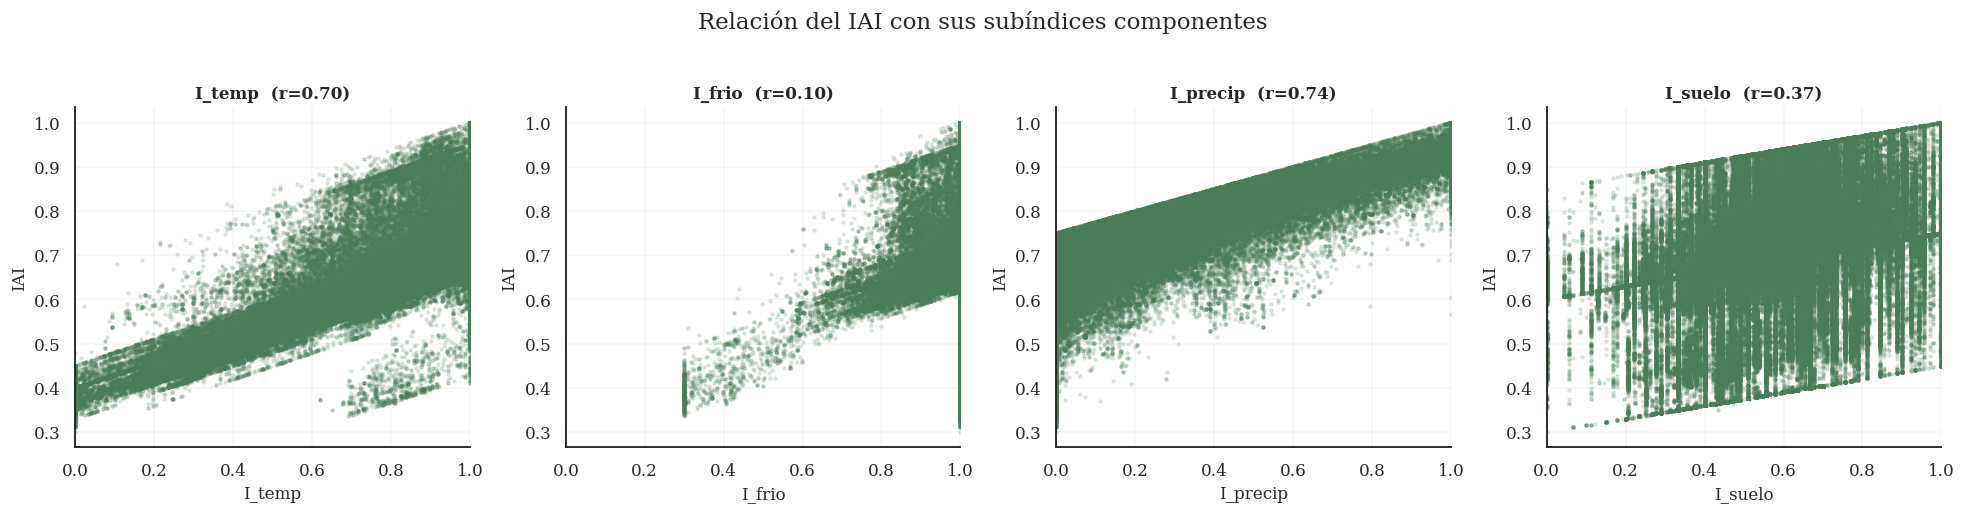

In [36]:
# Relación del IAI con cada subíndice
print("Media de cada subíndice:")
print(df.select(subindices).mean())

fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))
for i, sub in enumerate(subindices):
    ax = axes[i]
    x = df[sub].to_numpy()
    y = df["IAI"].to_numpy()
    ax.scatter(x, y, s=4, alpha=0.15, color=COLOR_GREEN)
    r = np.corrcoef(x, y)[0, 1]
    ax.set_title(f"{NOMBRES.get(sub, sub)}  (r={r:.2f})", fontsize=11)
    ax.set_xlabel(NOMBRES.get(sub, sub))
    ax.set_ylabel("IAI")
    ax.set_xlim(0, 1)
    ax.grid(alpha=0.2)

plt.suptitle("Relación del IAI con sus subíndices componentes", fontsize=15, y=1.03)
plt.tight_layout()
save(fig, "eda_03_iai_vs_subindices.png")
plt.show()

  [guardado] resultados_IAI\eda_04_medias_subindices.png


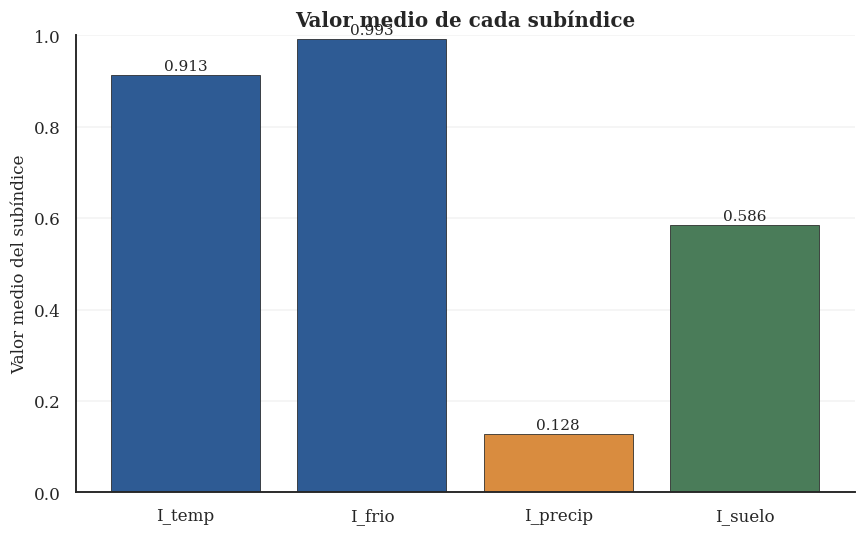

In [37]:
# Valor medio de cada subíndice (identifica los factores más limitantes)
medias_sub = [df[s].mean() for s in subindices]

fig, ax = plt.subplots(figsize=(8, 5))
barras = ax.bar([NOMBRES[s] for s in subindices], medias_sub,
                color=[COLOR_MAIN, COLOR_MAIN, COLOR_ORANGE, COLOR_GREEN],
                edgecolor="#222", linewidth=0.5)
for b, v in zip(barras, medias_sub):
    ax.text(b.get_x() + b.get_width()/2, v + 0.01, f"{v:.3f}",
            ha="center", fontsize=10)
ax.set_ylabel("Valor medio del subíndice")
ax.set_ylim(0, 1)
ax.set_title("Valor medio de cada subíndice")
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
save(fig, "eda_04_medias_subindices.png")
plt.show()

### El IAI frente a las variables base

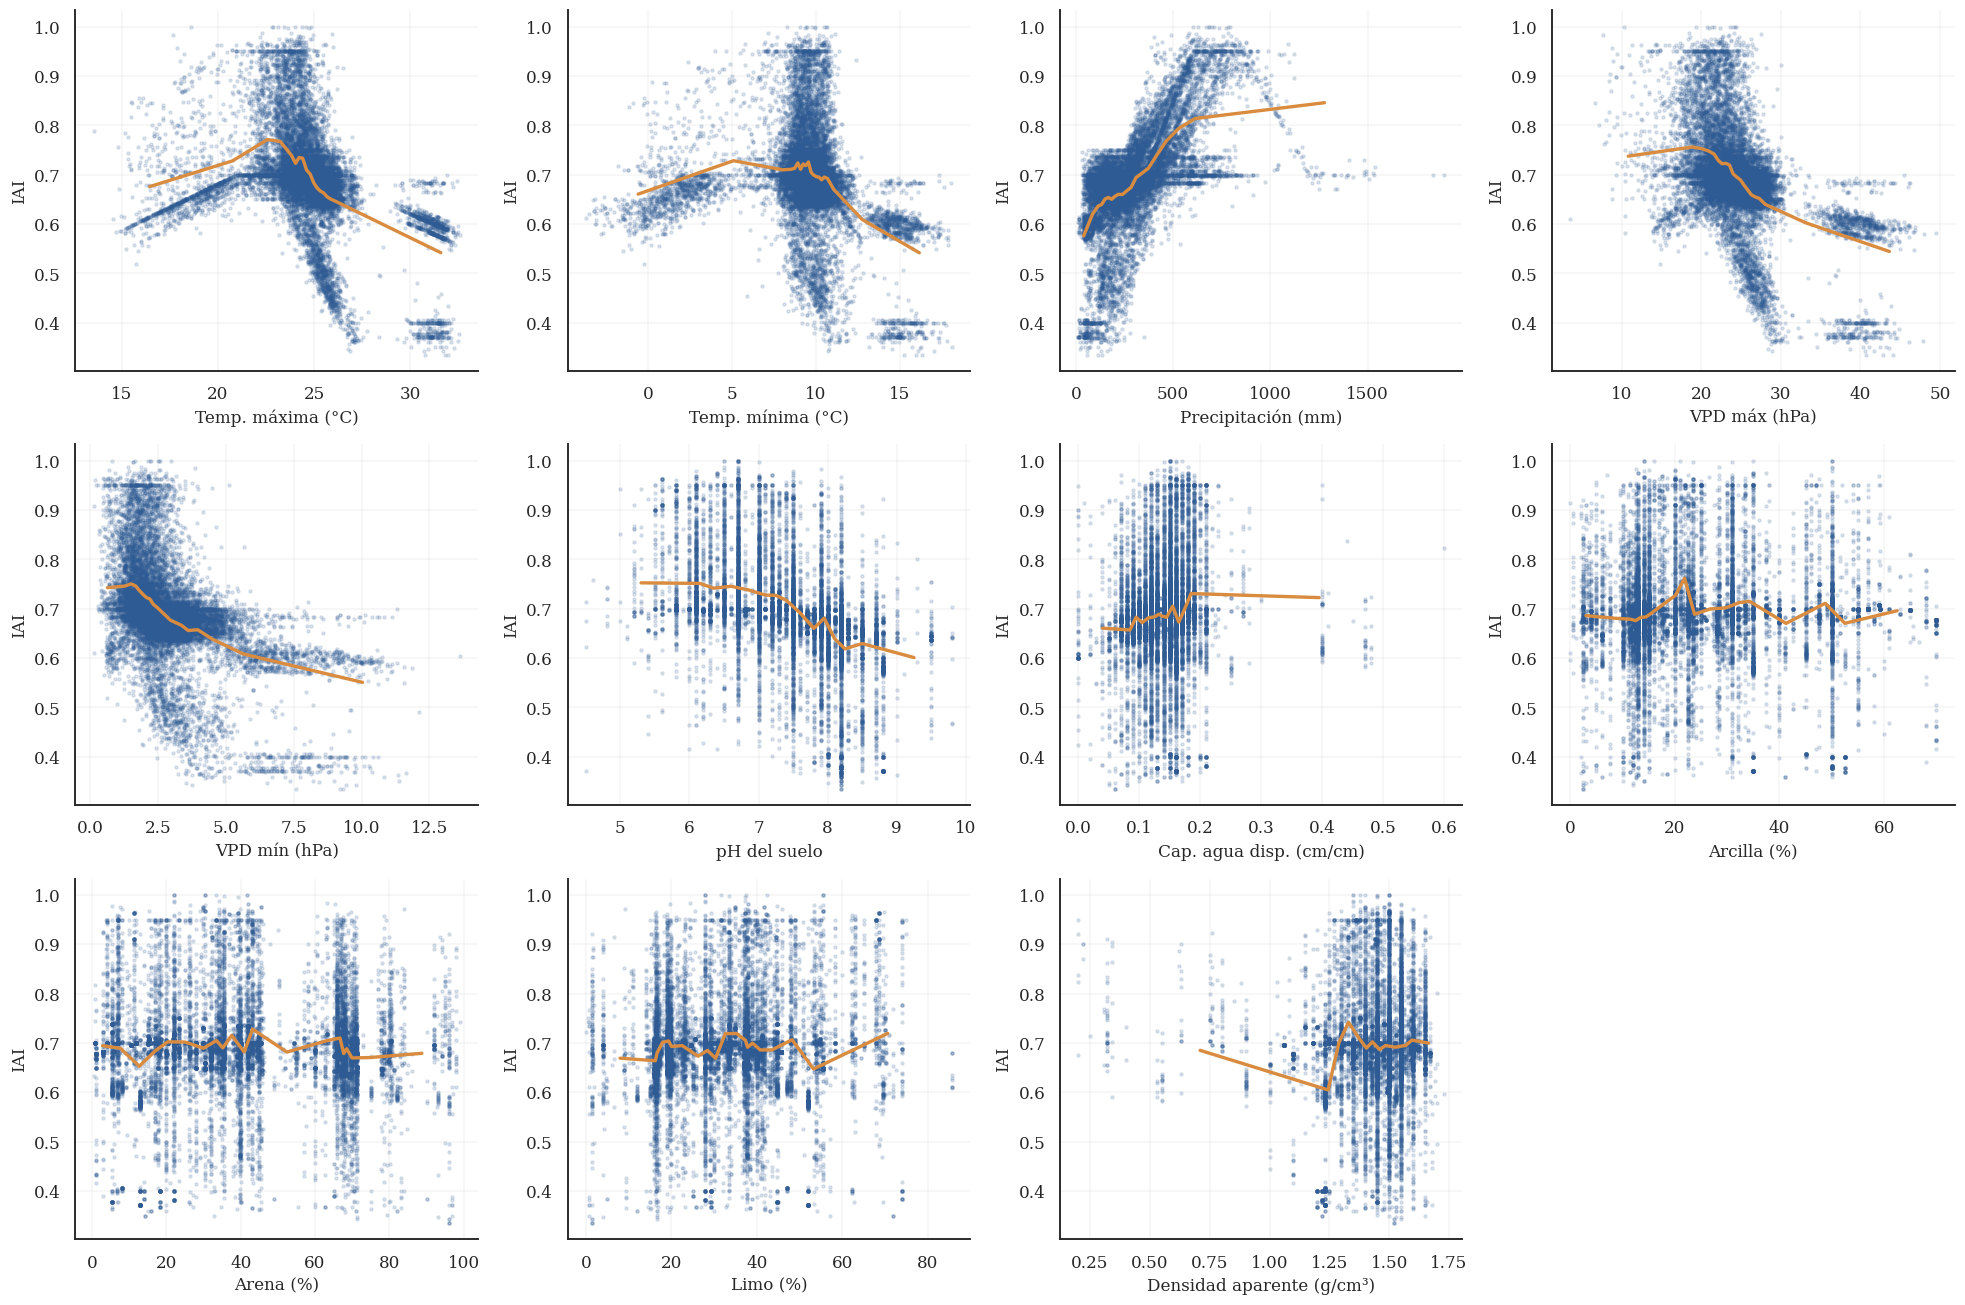

: 

In [ ]:
# Muestra para los scatter (eficiencia con datasets grandes)
np.random.seed(42)
n_muestra = min(15_000, df.shape[0])
idx = np.random.choice(df.shape[0], size=n_muestra, replace=False)
df_s = df[idx]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, var in enumerate(vars_base):
    ax = axes[i]
    x = df_s[var].to_numpy()
    y = df_s["IAI"].to_numpy()
    ax.scatter(x, y, s=4, alpha=0.15, color=COLOR_MAIN)

    # Línea de tendencia (media de IAI por percentiles de x)
    try:
        bins = np.percentile(x, np.linspace(0, 100, 21))
        bins = np.unique(bins)
        centros, medias = [], []
        for j in range(len(bins) - 1):
            m = (x >= bins[j]) & (x < bins[j + 1])
            if m.sum() > 0:
                centros.append((bins[j] + bins[j + 1]) / 2)
                medias.append(y[m].mean())
        ax.plot(centros, medias, color=COLOR_ORANGE, linewidth=2.2)
    except Exception:
        pass

    ax.set_xlabel(NOMBRES.get(var, var))
    ax.set_ylabel("IAI")
    ax.grid(alpha=0.2)

# Ocultar ejes sobrantes
for k in range(len(vars_base), len(axes)):
    axes[k].set_visible(False)

#plt.suptitle("Relación del IAI con las variables edafoclimáticas base",
 #            fontsize=15, y=1.0)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_02_iai_vs_variables_nt.png"), dpi=300, bbox_inches="tight")
plt.show()

Temperatura (máxima y mínima): ambas muestran una relación en forma de joroba, con un punto óptimo (alrededor de 23–25 °C en la máxima) a partir del cual la idoneidad empieza a caer. Es el comportamiento esperado: ni el frío ni el calor extremo favorecen a los cultivos.
Precipitación: es de las relaciones más marcadas. El IAI sube con fuerza a medida que aumenta la lluvia y se estabiliza a partir de los 500–600 mm. Esto confirma que el agua es un factor clave en California, donde la escasez de precipitación limita buena parte del territorio.
VPD (déficit de presión de vapor): tienen una relación inversa, cuanto mayor es el estrés evaporativo, menor es la idoneidad
Variables de suelo (pH, textura, densidad): su efecto es más suave y difuso. La línea se mantiene bastante plana, lo que indica que el suelo influye menos que el clima sobre el IAI global, aunque el pH muestra una ligera preferencia por valores cercanos a la neutralidad.

### Correlación

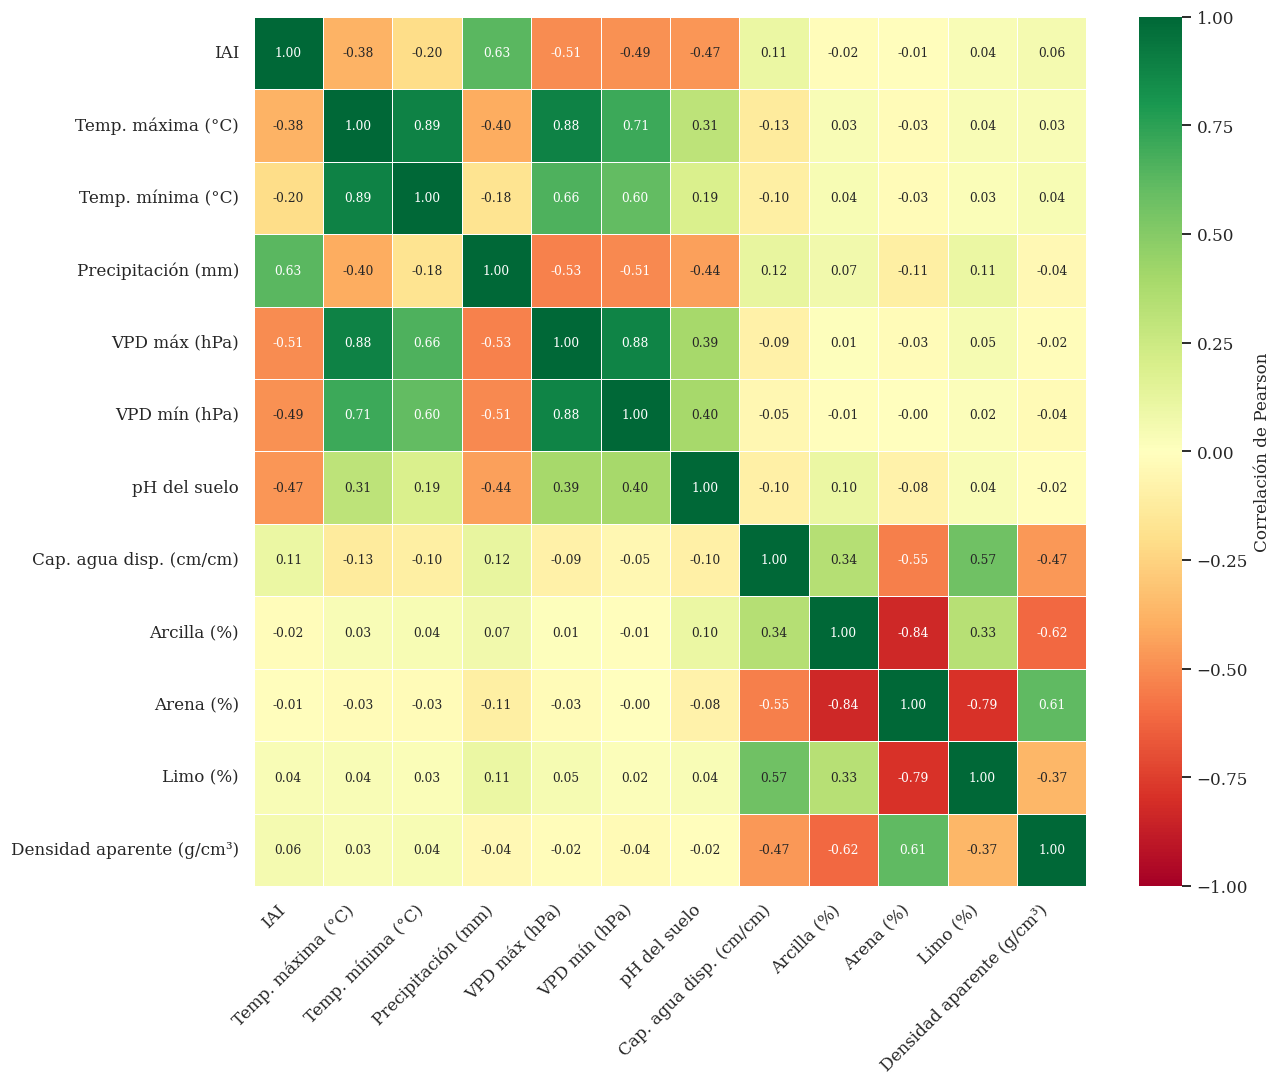

In [43]:
# Matriz de correlación
cols_corr = ["IAI"]  + vars_base
M = df.select(cols_corr).to_numpy()
corr = np.corrcoef(M, rowvar=False)

etiquetas = [NOMBRES.get(c, c) for c in cols_corr]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            xticklabels=etiquetas, yticklabels=etiquetas,
            vmin=-1, vmax=1, linewidths=0.5, linecolor="white",
            annot_kws={"size": 8}, ax=ax, cbar_kws={"label": "Correlación de Pearson"})
#ax.set_title("Matriz de correlación: IAI, subíndices y variables base", pad=14)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_06_matriz_correlacion_nt.png"), dpi=300, bbox_inches="tight")
plt.show()

In [40]:
# Comparar Pearson, Spearman e información mutua de cada variable con el IAI
vars_eval = subindices + vars_base
y = df["IAI"].to_numpy()

# Muestra para eficiencia (la información mutua es costosa en datasets grandes)
np.random.seed(42)
n = min(50_000, df.shape[0])
idx = np.random.choice(df.shape[0], size=n, replace=False)
y_s = y[idx]

resultados = []
for var in vars_eval:
    x = df[var].to_numpy()
    x_s = x[idx]
    pearson = np.corrcoef(x, y)[0, 1]
    spear = spearmanr(x, y).correlation
    mi = mutual_info_regression(x_s.reshape(-1, 1), y_s, random_state=42)[0]
    resultados.append({
        "variable": NOMBRES.get(var, var),
        "pearson": round(pearson, 3),
        "spearman": round(spear, 3),
        "info_mutua": round(mi, 3),
    })

df_corr = pl.DataFrame(resultados).sort("info_mutua", descending=True)
print(df_corr)

shape: (15, 4)
┌───────────────────────────┬─────────┬──────────┬────────────┐
│ variable                  ┆ pearson ┆ spearman ┆ info_mutua │
│ ---                       ┆ ---     ┆ ---      ┆ ---        │
│ str                       ┆ f64     ┆ f64      ┆ f64        │
╞═══════════════════════════╪═════════╪══════════╪════════════╡
│ I_suelo                   ┆ 0.368   ┆ 0.548    ┆ 2.805      │
│ Arena (%)                 ┆ -0.01   ┆ -0.018   ┆ 1.471      │
│ Limo (%)                  ┆ 0.035   ┆ 0.031    ┆ 1.427      │
│ pH del suelo              ┆ -0.469  ┆ -0.574   ┆ 1.167      │
│ Arcilla (%)               ┆ -0.016  ┆ 0.032    ┆ 1.15       │
│ Densidad aparente (g/cm³) ┆ 0.056   ┆ 0.062    ┆ 0.9        │
│ Cap. agua disp. (cm/cm)   ┆ 0.106   ┆ 0.142    ┆ 0.895      │
│ I_temp                    ┆ 0.699   ┆ 0.545    ┆ 0.832      │
│ Temp. máxima (°C)         ┆ -0.379  ┆ -0.44    ┆ 0.829      │
│ I_precip                  ┆ 0.744   ┆ 0.668    ┆ 0.816      │
│ Precipitación (mm)     

Para complementar la correlación de Pearson que solo mide relaciones lineales, se calcularon también la correlación de Spearman (relaciones monótonas) y la información mutua (cualquier tipo de dependencia, lineal o no). Con esto tenemos un overview del panorama más amplio ya que como vimos en los graficos las variables no tienen una relación lineal con IAI.

- El caso de la temperatura máxima muestra la importancia de usar la información mutua, ya que mientras que su correlación de Pearson es prácticamente nula (-0.01), su información mutua es una de las más altas (0.64). 


## 5. Resumen del IAI por cultivo

In [41]:
# IAI medio por cultivo (tabla)
resumen_cultivo = (
    df.group_by("crop_name")
      .agg([
          pl.col("IAI").mean().alias("IAI_medio"),
          pl.col("IAI").median().alias("IAI_mediana"),
          pl.col("IAI").std().alias("IAI_std"),
          pl.len().alias("n"),
      ])
      .sort("IAI_medio", descending=True)
)
print(resumen_cultivo)

shape: (12, 5)
┌──────────────┬───────────┬─────────────┬──────────┬────────┐
│ crop_name    ┆ IAI_medio ┆ IAI_mediana ┆ IAI_std  ┆ n      │
│ ---          ┆ ---       ┆ ---         ┆ ---      ┆ ---    │
│ str          ┆ f64       ┆ f64         ┆ f64      ┆ u32    │
╞══════════════╪═══════════╪═════════════╪══════════╪════════╡
│ Strawberries ┆ 0.788826  ┆ 0.75654     ┆ 0.100297 ┆ 2117   │
│ Almonds      ┆ 0.736863  ┆ 0.713333    ┆ 0.089027 ┆ 136199 │
│ Walnuts      ┆ 0.729688  ┆ 0.696667    ┆ 0.08726  ┆ 42355  │
│ Tomatoes     ┆ 0.722022  ┆ 0.7         ┆ 0.083314 ┆ 26379  │
│ Grapes       ┆ 0.716938  ┆ 0.701923    ┆ 0.075697 ┆ 83068  │
│ Pistachios   ┆ 0.714191  ┆ 0.7         ┆ 0.077217 ┆ 38503  │
│ Rice         ┆ 0.706142  ┆ 0.7         ┆ 0.019373 ┆ 51469  │
│ Cotton       ┆ 0.682599  ┆ 0.6825      ┆ 0.019173 ┆ 26125  │
│ Alfalfa      ┆ 0.682036  ┆ 0.670833    ┆ 0.08319  ┆ 136325 │
│ Oranges      ┆ 0.670082  ┆ 0.671739    ┆ 0.022301 ┆ 10663  │
│ Wheat        ┆ 0.56582   ┆ 0.54345    

C:\Users\lesli\AppData\Local\Temp\ipykernel_14060\1288147232.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(datos_box, labels=orden, patch_artist=True,


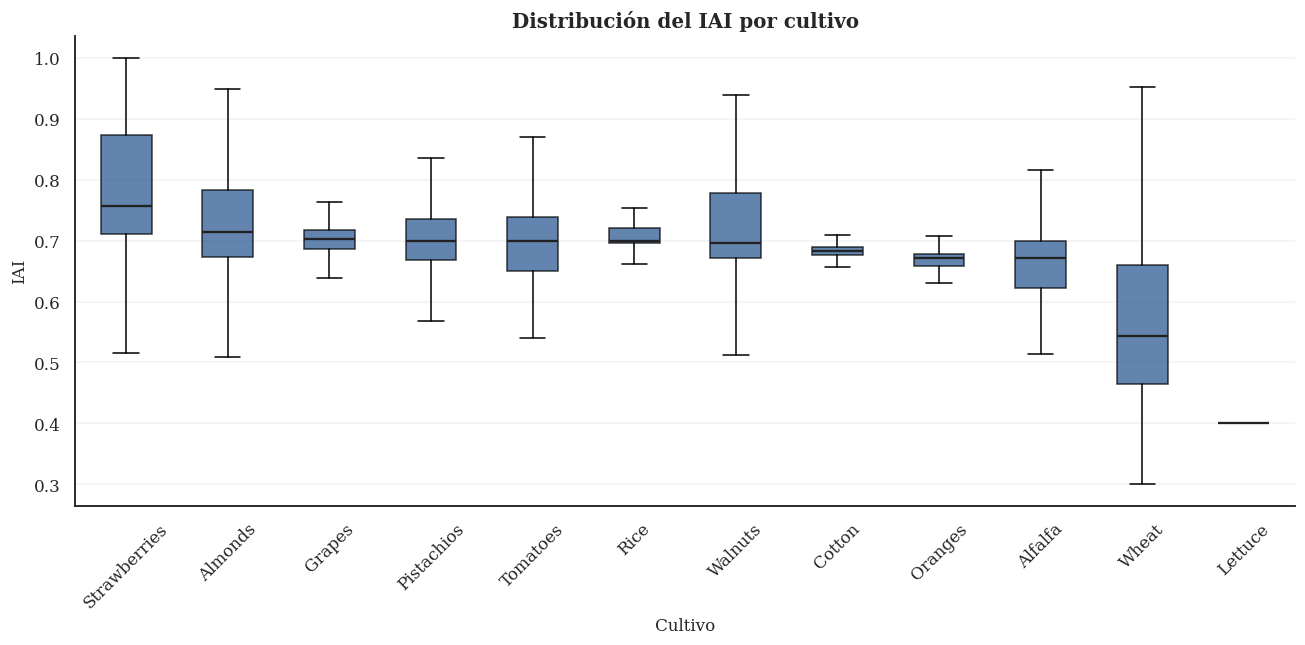

In [42]:
# Boxplot del IAI por cultivo, ordenado por mediana
orden = (df.group_by("crop_name")
           .agg(pl.col("IAI").median().alias("m"))
           .sort("m", descending=True)["crop_name"].to_list())

datos_box = [df.filter(pl.col("crop_name") == c)["IAI"].to_numpy() for c in orden]

fig, ax = plt.subplots(figsize=(12, 6))
bp = ax.boxplot(datos_box, labels=orden, patch_artist=True,
                showfliers=False, medianprops=dict(color="#222", linewidth=1.5))
for patch in bp["boxes"]:
    patch.set_facecolor(COLOR_MAIN)
    patch.set_alpha(0.75)
ax.set_ylabel("IAI")
ax.set_xlabel("Cultivo")
ax.set_title("Distribución del IAI por cultivo")
ax.tick_params(axis="x", rotation=45)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "eda_05_iai_por_cultivo.png"), dpi=300, bbox_inches="tight")
plt.show()